Ce notebook traite des points suivants:

1. Chargement de la grille temporelle traitée
2. Entraînement par validation croisée avec GroupKFold
3. Recherche de seuil dans toutes les zones de sécurité
4. (Facultatif) Optimisation des hyperparamètres avec Optuna
5. Entraînement et sauvegarde du modèle final
6. Évaluation sur l’ensemble de test

In [25]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.config import (
    FEATURE_COLUMNS, SAFETY_ZONES_KM, RISK_THRESHOLD,
    XGB_DEFAULT_PARAMS, HORIZON_MIN
)
from src.training.model import (
    train_with_cross_validation, smooth_probabilities, train_final_model
)
from src.training.tuning import (
    build_objective_maximize_gain, run_optuna
)
from src.evaluation.metrics import (
    compute_alert_masks, find_best_threshold,
    print_evaluation_report, apply_irrevocable_decision, compute_gain
)
from src.pipeline.predict import save_model, load_model, predict_batch

from config.config import CONFIRMATION_WINDOW

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Chargement et préparation des données

In [26]:
#Chargement et préparation

df_train = pd.read_parquet('../data/grid_train.parquet')
df_test  = pd.read_parquet('../data/grid_test.parquet')

# La cible : danger dans les 30 min, zone 20km
TARGET_COL = f'target_{HORIZON_MIN}m_20km'

features    = [c for c in FEATURE_COLUMNS if c in df_train.columns]
X_all       = df_train[features]
y_all       = df_train[TARGET_COL]
groups_all  = df_train['storm_group_id']

print(f"Dataset: {len(df_train):,} lignes | {groups_all.nunique()} orages")
print(f"Équilibre des classes ({TARGET_COL}) : {y_all.mean():.2%} positif")

Dataset: 209,254 lignes | 2627 orages
Équilibre des classes (target_30m_20km) : 56.58% positif


## 2. Entraînement par validation croisée avec GroupKFold

In [27]:
oof_preds, fold_models = train_with_cross_validation(
    X_all, y_all, groups_all, params=XGB_DEFAULT_PARAMS,
    n_splits=2
)

df_train['proba_brute']  = oof_preds
df_train['proba_lissee'] = smooth_probabilities(df_train, raw_proba_col='proba_brute')

  Pli 1/2...
  Pli 2/2...
Validation croisée terminée.


## 3. Recherche de seuil dans toutes les zones de sécurité

In [28]:
results = find_best_threshold(
    df_train,
    safety_zones_km= [3], # [3, 5, 7, 10, 15, 20],
    risk_threshold=RISK_THRESHOLD,
    confirmation_window=CONFIRMATION_WINDOW,
    horizon_min=HORIZON_MIN,
)


print_evaluation_report(results, zone_km=3)


Rapport d’évaluation — zone d’audit : 3 km
  Seuil            : 63.930%
  Gain total       : 49198 minutes
  Risque R         : 1.995%
----------------------------------------------------------------------
  Gain moyen/orage : 18.7 min
  Gain médian      : 17.0 min
  Écart-type       : 13.1 min
  Max / Min        : 212.0 / 0.0 min


## 4. Optimisation des hyperparamètres avec Optuna (facultatif, déjà de bons résultats avec les paramètres par défaut)

In [29]:
RUN_OPTUNA = False

if RUN_OPTUNA:
    objective = build_objective_maximize_gain(X_all, y_all, groups_all, df_train)
    study = run_optuna(
        objective,
        n_trials=10,
        best_known_params=XGB_DEFAULT_PARAMS,
    )
    print('Best params:', study.best_params)

## 5. Entraînement du modèle final sur l’ensemble des données d’entraînement

In [30]:
model_final = train_final_model(X_all, y_all, params=XGB_DEFAULT_PARAMS)
save_model(model_final, '../models/xgb_final.pkl')

Entraînement du modèle final sur 100% des données...
Modèle final prêt.
Modèle sauvegardé dans ../models/xgb_final.pkl


## 6. Importance des features

                  Feature  Importance
      activity_drop_ratio    0.466796
minutes_since_last_strike    0.165849
          last_known_dist    0.065443
   activity_count_last_5m    0.058761
     ratio_ic_cg_last_20m    0.025001
     dist_centroid_actuel    0.024389
             dist_last_5m    0.019377
        count_ic_last_20m    0.017652
            cum_n_strikes    0.016797
  activity_count_last_20m    0.015393
        count_cg_last_20m    0.014299
   dist_centroid_proj_30m    0.010121
            dist_last_20m    0.008832
                month_cos    0.008709
                month_sin    0.007697


/tmp/ipykernel_730083/432176608.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')


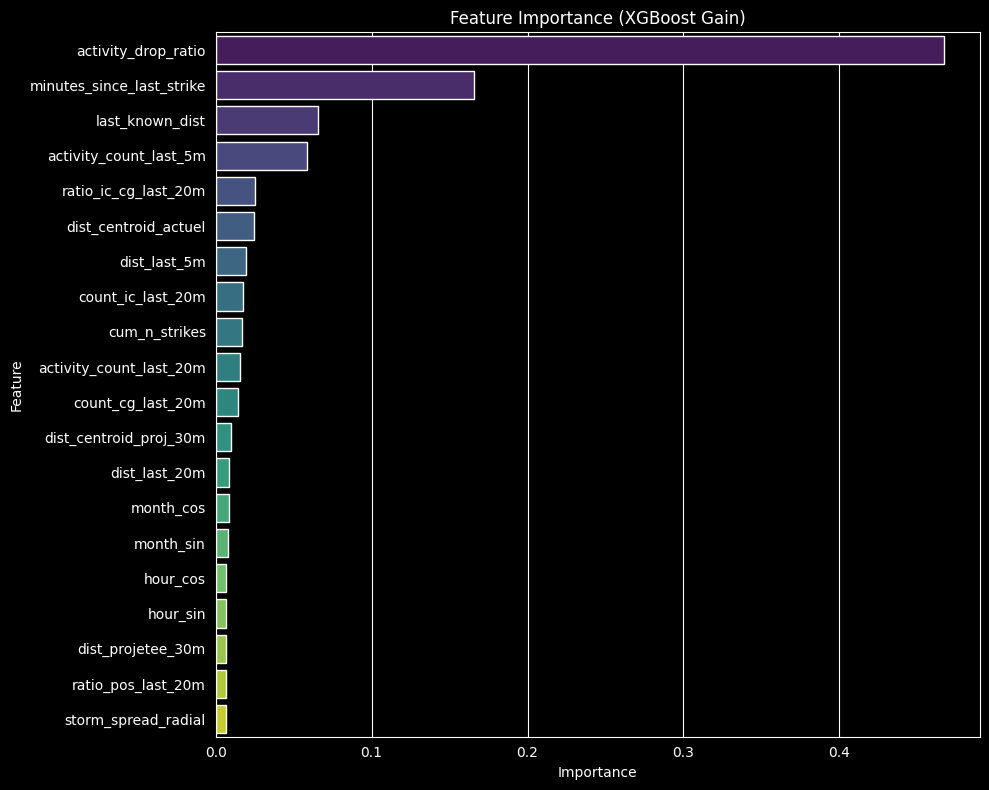

In [31]:
import pandas as pd

df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_final.feature_importances_
}).sort_values('Importance', ascending=False)

print(df_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')
plt.title('Feature Importance (XGBoost Gain)')
plt.tight_layout()
plt.show()

## 7. Evaluation sur l’ensemble de test

In [34]:
results_test = predict_batch(
    model_final,
    df_test,
    safety_zones_km=[3],
    risk_threshold=RISK_THRESHOLD,
)


Données brutes détectées. Construction de la grille temporelle...
Construction de la grille temporelle (horizon=30m, zones=[3]km)...
Assemblage de la grille finale...


KeyError: 'count_cg_20km'

## 8. Visualisation d'une courbe de probabilité pour un orage

In [33]:
def plot_storm_radar(
    df: pd.DataFrame,
    storm_id: int,
    threshold: float,
    confirmation_window: int = 10,
) -> None:
    df_s = df[df['storm_group_id'] == storm_id].copy()
    if df_s.empty:
        print(f"Storm {storm_id} not found.")
        return


    if 'count_cg_zone' in df_s.columns and df_s['count_cg_zone'].sum() > 0:
        first = df_s[df_s['count_cg_zone'] > 0].index[0]
        df_s = df_s.loc[first:].reset_index(drop=True)

    t = np.arange(len(df_s))
    decision_ia = (df_s['proba_lissee'] > threshold).rolling(window=confirmation_window, min_periods=1).max()

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(t, df_s['proba_lissee'], color='dodgerblue', linewidth=2, label='AI probability')
    ax1.axhline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold:.3f})')
    ax1.fill_between(t, df_s['proba_lissee'], threshold,
                     where=(decision_ia == 0), color='green', alpha=0.15, label='Opening window')

    if 'count_cg_zone' in df_s.columns and df_s['count_cg_zone'].sum() > 0:
        last_danger = np.where(df_s['count_cg_zone'] > 0)[0][-1]
        ax1.axvline(last_danger, color='black', linestyle='-.', linewidth=2, label='Last strike')
        ax1.axvline(last_danger + 30, color='purple', linestyle=':', linewidth=2, label='Human baseline end')

    ax1.set_xlabel('Minutes since alert start')
    ax1.set_ylabel('Danger probability', color='dodgerblue')
    ax1.set_ylim(0, 1.05)
    ax1.legend(loc='upper right')
    plt.title(f'Storm #{storm_id} — threshold={threshold:.3f}')
    plt.tight_layout()
    plt.show()


# Example: plot storm #1 with the best threshold found for 3 km zone
if 3 in results_test and results_test[3]['threshold'] > 0:
    plot_storm_radar(df_train, storm_id=df_train['storm_group_id'].iloc[0],
                     threshold=results_test[3]['threshold'])